# Notebook 00: Define Area of Interest

## 1 Connect Google Drive (Colab only)

This section is only required when running in **Google Colab** and your project/data are stored in Google Drive.

- Mounting Drive makes your repository and datasets accessible under `/content/drive`.
- If you run this notebook locally (Jupyter / VS Code), **skip this section**.

**Expected structure (Drive)**
After mounting, your project root should contain:
- `notebooks/`
- `src/`
- `config.yml` (or `config.yaml`)

Proceed to the code cell below to mount Drive.

In [1]:
from google.colab import drive
import os

# Check if the drive is mounted
if os.path.exists('/content/drive'):
    # Try to unmount
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted")
    except:
        print("Unmount failed, the drive might not be mounted or busy")

# Mount the drive
drive.mount('/content/drive')

Successfully unmounted
Mounted at /content/drive


**Troubleshooting:**  
- If Colab becomes disconnected, Reconnect the runtime and rerun the mounting cell.
- If we receive an error such as `Mountpoint must not already contain files`, delete all the sub-folders under "/content/drive" from the Files panel before retrying. We need to delete these one by one starting from the innermost folders, until the last "drive" folder is deleted.


## 2 Install packages (only if needed)

In most cases, **Google Colab already includes the packages required** for this workflow. The most common missing dependency is **`netCDF4`** (NetCDF I/O support).

### Check what is already installed (Colab)
Before installing anything, you can inspect the current environment by running `!pip list`.

- If all required packages are present and only `netCDF4` is missing, install **only `netCDF4`**.
- If other required packages are missing from `!pip list`, install them **together with** `netCDF4` in the code cell below.

### Local Jupyter note
If you are running in a **local environment** (Jupyter / VS Code), assume all dependencies were installed when preparing the environment following the **main repository README**. In that case, you can skip this section.

Proceed to the code cell below only when installation is necessary.

In [2]:
# In Google Colab, almost all packages already available, except netCDF4
# We also need pyogrio is an alternative C-based engine for Geopandas that reads large vector files exponentially faster.
!pip install netCDF4 pyogrio

Once this completes, you’ll be ready to load and manipulate spatial data (Sections 2.1 and beyond) and visualize your results on real-world map projections.

## 3 Project Folders

Next, we establish a clear folder structure on your mounted Drive so that raw inputs, downloads, intermediate masks, and final outputs each live in their own dedicated directory. The snippet below:

- Declares a single main project folder
- Builds subpaths for input data, downloaded files, mask outputs, and final results
- Ensures each required directory exists, creating it if necessary

A well-organized directory layout makes it easy to trace where every file came from and prevents accidental overwrites—setting you up for a reproducible, scalable workflow.


In [3]:
# Import library
import os

# Configurable Directory
# Base folder on Google Drive for this project
main_dir = '/content/drive/MyDrive/hybrid-bias-correction'

# Define key subfolders
input_dir     = f'{main_dir}/data/input'      # RAW input data goes here
downloads_dir = f'{main_dir}/data/downloads'  # All downloaded files
mask_dir      = f'{main_dir}/data/mask'       # Generated land masks
output_dir    = f'{main_dir}/data/output'     # Final outputs & results

# List of directories to ensure exist
for d in [input_dir, downloads_dir, mask_dir, output_dir]:
    os.makedirs(d, exist_ok=True)
    print(f"✅ Ensured directory exists: {d}")


✅ Ensured directory exists: /content/drive/MyDrive/hybrid-bias-correction/data/input
✅ Ensured directory exists: /content/drive/MyDrive/hybrid-bias-correction/data/downloads
✅ Ensured directory exists: /content/drive/MyDrive/hybrid-bias-correction/data/mask
✅ Ensured directory exists: /content/drive/MyDrive/hybrid-bias-correction/data/output


## 4 Area of Interest (AOI)

Accurate boundary delineation is essential for robust geospatial analysis. In our workflow, the IMERG grid—with its 0.1° spatial resolution—serves as the fundamental reference for all outputs. To maintain consistency between different datasets and ensure reliable spatial analysis, it is crucial to generate a global land mask that exactly conforms to the IMERG grid. This approach guarantees that all output data layers are aligned and comparable.

There are many global country (admin0) boundary datasets used by humanitarian and international development professionals. Some popular examples include:
- [Natural Earth](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-0-countries/)
- [GADM](https://gadm.org/download_world.html)
- [geoBoundaries](https://www.geoboundaries.org/globalDownloads.html)
- [Fieldmaps.io](https://fieldmaps.io/data/adm0)

For this exercise, we will use the global admin0 boundary from Fieldmaps.io to develop a global land mask at 0.1° resolution.

Furthermore, the consistent global land mask is the key starting point for subsequent processes: users can easily clip this mask to their preferred Area of Interest (AOI), which is described in detail in Section 2.2.



### 4.1 Creating a Global Land Mask

Now that our workspace is organized, we’ll generate a world‐wide land mask perfectly aligned to the IMERG 0.1° grid. This mask will underpin **all** later AOI extractions and ensures that every subsequent raster operation uses the same spatial reference.

The code below:

1. **Downloads** a zipped GeoPackage of admin-0 boundaries from Fieldmaps.io  
2. **Extracts** the vector file into our downloads folder  
3. **Defines** a global 0.1° raster grid spanning latitude [–90, 90] and longitude [–180, 180]  
4. **Rasterizes** each country polygon to a mask where land = 1 and water = NaN  
5. **Builds** an xarray DataArray and **saves** it as a NetCDF for downstream use

This process will download a global dataset with size around **1 GB**, make sure your internet is fast.


In [10]:
# Download and build global land mask
import os
import zipfile
import subprocess
import time
import geopandas as gpd
import numpy as np
from rasterio import features
from affine import Affine
import xarray as xr
from tqdm import tqdm

def format_size(bytes_size):
    """Helper to format bytes into MB/GB for readable console output."""
    for unit in ['B', 'KB', 'MB', 'GB']:
        if bytes_size < 1024.0:
            return f"{bytes_size:.2f} {unit}"
        bytes_size /= 1024.0

# Get the admin0 in GPKG format
def download_and_extract_gpkg(url: str, extract_dir: str, zip_fname: str = "adm0_polygons.gpkg.zip"):
    """
    Download a zipped GPKG from `url` into `zip_fname` and extract into `extract_dir`.
    """
    try:
        print(f"==================================================")
        print(f"⬇️ STEP 1: DOWNLOADING DATA")
        print(f"==================================================")
        print(f"⏳ Target URL: {url}")

        t0 = time.time()
        # Use wget via subprocess for maximum speed in Colab
        subprocess.run(
            ["wget", "-q", "--show-progress", "-O", zip_fname, url],
            check=True
        )
        download_time = time.time() - t0

        file_size = os.path.getsize(zip_fname)
        print(f"✔️ Download complete! Saved {format_size(file_size)} in {download_time:.1f} seconds.\n")

        print(f"==================================================")
        print(f"📦 STEP 2: EXTRACTING ARCHIVE")
        print(f"==================================================")
        t1 = time.time()

        with zipfile.ZipFile(zip_fname, 'r') as z:
            members = z.infolist()
            print(f"⏳ Found {len(members)} file(s) in ZIP. Starting extraction...")

            # Add a progress bar for the extraction process
            for member in tqdm(members, desc="Extracting files"):
                z.extract(member, extract_dir)

        extract_time = time.time() - t1
        print(f"✔️ Extraction finished in {extract_time:.1f} seconds.\n")

    except subprocess.CalledProcessError as e:
        raise RuntimeError(f"wget failed to download the file: {e}")
    except Exception as e:
        raise RuntimeError(f"Failed to extract GPKG: {e}")

# Rasterize the global land polygon
def rasterize_global_land(gpkg_path: str, out_nc: str, resolution: float = 0.1):
    """
    Read country boundaries from `gpkg_path`, rasterize to a global land mask at `resolution`,
    and save to NetCDF `out_nc`.
    """
    try:
        print(f"==================================================")
        print(f"🗺️ STEP 3: LOADING VECTOR DATA")
        print(f"==================================================")

        gpkg_size = os.path.getsize(gpkg_path)
        print(f"⏳ Reading GPKG file ({format_size(gpkg_size)}) from {gpkg_path} ...")
        print("   (Using 'pyogrio' engine for fast I/O - please wait)")

        t2 = time.time()
        gdf = gpd.read_file(gpkg_path, engine="pyogrio")
        load_time = time.time() - t2
        print(f"✔️ Loaded {len(gdf)} MultiPolygons into memory in {load_time:.1f} seconds.\n")

        print(f"==================================================")
        print(f"✂️ STEP 3.5: SIMPLIFYING & PROTECTING ISLANDS")
        print(f"==================================================")
        print(f"⏳ Exploding MultiPolygons to evaluate every single island...")

        t_simp = time.time()

        # FIX: Explode groups into single islands so we can track each one individually
        gdf = gdf.explode(ignore_index=True)
        print(f"⏳ Tracking {len(gdf)} individual islands/polygons...")

        # 1. Backup the original shapes
        orig_geoms = gdf.geometry.copy()

        # 2. Perform the fast, aggressive simplification
        gdf['geometry'] = gdf.geometry.simplify(tolerance=0.02, preserve_topology=False)

        # 3. Identify any tiny islands that collapsed
        collapsed_mask = gdf.geometry.is_empty | ~gdf.geometry.type.str.contains('Polygon')
        num_collapsed = collapsed_mask.sum()

        # 4. Restore those specific tiny islands
        if num_collapsed > 0:
            print(f"⏳ Rescuing {num_collapsed} tiny islands that vanished... restoring originals.")
            gdf.loc[collapsed_mask, 'geometry'] = orig_geoms[collapsed_mask]

        simp_time = time.time() - t_simp
        print(f"✔️ Polygons simplified in {simp_time:.1f} seconds. All tiny islands preserved!\n")

        print(f"==================================================")
        print(f"⚙️ STEP 4: RASTERIZING AT {resolution}° RESOLUTION")
        print(f"==================================================")
        # Define global grid
        lon_min, lon_max = -180, 180
        lat_min, lat_max = -90, 90
        width = int((lon_max - lon_min) / resolution)
        height = int((lat_max - lat_min) / resolution)
        transform = Affine.translation(lon_min, lat_max) * Affine.scale(resolution, -resolution)

        print(f"⏳ Target Grid: {width} columns × {height} rows (Total pixels: {width*height:,})")
        print(f"⏳ Rasterizing polygons (1=land, NaN=water)...")

        t3 = time.time()
        shapes = ((geom, 1) for geom in gdf.geometry)
        mask = features.rasterize(
            shapes,
            out_shape=(height, width),
            transform=transform,
            fill=np.nan,
            dtype="float32",
            all_touched=True
        )
        raster_time = time.time() - t3
        print(f"✔️ Rasterization complete in {raster_time:.1f} seconds.\n")

        print(f"==================================================")
        print(f"💾 STEP 5: SAVING NETCDF")
        print(f"==================================================")
        print("⏳ Building xarray structure and saving to disk...")

        t4 = time.time()
        lon = lon_min + (np.arange(width) + 0.5) * resolution
        lat = lat_max - (np.arange(height) + 0.5) * resolution
        da = xr.DataArray(mask, coords={'lat': lat, 'lon': lon}, dims=['lat', 'lon'], name='land')
        da.attrs.update({
            "description": "Global land mask (1=land, NaN=water)",
            "grid_resolution": f"{resolution}°",
            "units": "1 / NaN"
        })

        da.to_netcdf(out_nc)
        save_time = time.time() - t4

        nc_size = os.path.getsize(out_nc)
        print(f"✔️ NetCDF saved! ({format_size(nc_size)}) in {save_time:.1f} seconds.\n")
        print(f"🎉 SUCCESS: World land mask generated at {out_nc}")

    except Exception as e:
        raise RuntimeError(f"Error during rasterization or saving NetCDF: {e}")

def main():
    try:
        # Define directories (adjust main_dir as needed)
        bdir = os.path.join(main_dir, 'data/downloads/boundary')
        wdir = os.path.join(main_dir, 'data/mask/world')
        os.makedirs(bdir, exist_ok=True)
        os.makedirs(wdir, exist_ok=True)

        gpkg_url = "https://data.fieldmaps.io/adm0/osm/intl/adm0_polygons.gpkg.zip"

        # Start total timer
        total_start = time.time()

        download_and_extract_gpkg(gpkg_url, bdir)

        gpkg = os.path.join(bdir, "adm0_polygons.gpkg")
        out_nc = os.path.join(wdir, "wld_land_mask.nc")
        rasterize_global_land(gpkg, out_nc)

        total_time = time.time() - total_start
        print(f"==================================================")
        print(f"⏱️ TOTAL PIPELINE TIME: {total_time:.1f} seconds")
        print(f"==================================================")

    except Exception as e:
        print(f"\n❌ SCRIPT FAILED: {e}")

# Run
if __name__ == "__main__":
    main()

⬇️ STEP 1: DOWNLOADING DATA
⏳ Target URL: https://data.fieldmaps.io/adm0/osm/intl/adm0_polygons.gpkg.zip
✔️ Download complete! Saved 919.06 MB in 13.4 seconds.

📦 STEP 2: EXTRACTING ARCHIVE
⏳ Found 1 file(s) in ZIP. Starting extraction...


Extracting files: 100%|██████████| 1/1 [00:24<00:00, 24.91s/it]


✔️ Extraction finished in 24.9 seconds.

🗺️ STEP 3: LOADING VECTOR DATA
⏳ Reading GPKG file (1.27 GB) from /content/drive/MyDrive/hybrid-bias-correction/data/downloads/boundary/adm0_polygons.gpkg ...
   (Using 'pyogrio' engine for fast I/O - please wait)
✔️ Loaded 318 MultiPolygons into memory in 11.8 seconds.

✂️ STEP 3.5: SIMPLIFYING & PROTECTING ISLANDS
⏳ Exploding MultiPolygons to evaluate every single island...
⏳ Tracking 803342 individual islands/polygons...
⏳ Rescuing 796754 tiny islands that vanished... restoring originals.
✔️ Polygons simplified in 23.0 seconds. All tiny islands preserved!

⚙️ STEP 4: RASTERIZING AT 0.1° RESOLUTION
⏳ Target Grid: 3600 columns × 1800 rows (Total pixels: 6,480,000)
⏳ Rasterizing polygons (1=land, NaN=water)...
✔️ Rasterization complete in 119.2 seconds.

💾 STEP 5: SAVING NETCDF
⏳ Building xarray structure and saving to disk...
✔️ NetCDF saved! (24.77 MB) in 0.1 seconds.

🎉 SUCCESS: World land mask generated at /content/drive/MyDrive/hybrid-bias-

With this NetCDF now in place, we can move on to Section 4.2 to clip it to any Area of Interest—whether by country code, bounding box, or our own custom shapefile.

### 4.2 AOI Options

Defining a precise Area of Interest (AOI) is crucial for targeted analysis. There are at least three options to obtain the AOI: (1) using publicly available administrative boundaries, (2) using a bounding box or predefined polygon, or (3) using our own data.

Using the global land mask created in Section 4.1, we can clip the world mask to any of these AOIs. The following subsections describe sample workflows for each approach, including scripts to extract the AOI from
- Global administrative boundaries (Section 4.2.1)
- Custom bounding boxes (Section 4.2.2)
- User-supplied datasets (Section 4.2.3).

For a smoother experience, we recommend using administrative boundaries from the first option, but we are free to choose whichever option best fits our needs!

By accurately isolating the focus area using one of these methods, we ensure that the data processing is relevant and efficient for specific requirements.

#### 4.2.1 Country Boundaries

In this section, we utilize publicly available administrative boundary datasets to select a desired region. This option is often preferred because it provides country boundaries, which are widely used by many humanitarian professionals.

Let’s first check the attributes of the country boundary dataset we have downloaded. This will help us identify the fields containing the ISO3 country code and the country name, which we will use to filter for specific countries.


In [11]:
# Inspect the GeoPackage attributes
import os
import geopandas as gpd

# Path to your GPKG
gpkg_file = os.path.join(main_dir, 'data/downloads/boundary/adm0_polygons.gpkg')

print("⏳ Peeking at the first 5 rows of the 1.2GB file...")

# OPTIMIZATION: Use 'pyogrio' for speed, and 'max_features=5' to stop reading after 5 rows
gdf = gpd.read_file(gpkg_file, engine="pyogrio", max_features=5)

# Print the column names
print("\n✔️ Available columns:")
print(list(gdf.columns))

print("\n✔️ Data preview:")
# Use display() instead of print() for a beautifully formatted interactive table in Colab!
display(gdf)

⏳ Peeking at the first 5 rows of the 1.2GB file...

✔️ Available columns:
['adm0_id', 'adm0_src', 'adm0_name', 'adm0_name1', 'adm0_name2', 'iso_cd', 'iso_2', 'iso_3', 'iso_3_grp', 'region3_cd', 'region3_nm', 'region2_cd', 'region2_nm', 'region1_cd', 'region1_nm', 'status_cd', 'status_nm', 'wld_date', 'wld_update', 'wld_land', 'wld_view', 'wld_notes', 'geometry']

✔️ Data preview:


,adm0_id,adm0_src,adm0_name,adm0_name1,adm0_name2,iso_cd,iso_2,iso_3,iso_3_grp,region3_cd,...,region1_cd,region1_nm,status_cd,status_nm,wld_date,wld_update,wld_land,wld_view,wld_notes,geometry
0,ABW-20250729,ABW,Aruba (Neth.),Aruba,NaN,533,AW,ABW,NLD,29,...,19,Americas,5,Territory/Self-governing territory,2025-02-24,2025-07-29,osm,intl,None,"MULTIPOLYGON (((-69.97919 12.4655, -69.97918 1..."
1,AFG-20250729,AFG,Afghanistan,Afghanistan,NaN,4,AF,AFG,AFG,34,...,142,Asia,1,State,2025-02-24,2025-07-29,osm,intl,None,"MULTIPOLYGON (((74.88904 37.23228, 74.88871 37..."
2,AGO-20250729,AGO,Angola,Angola,NaN,24,AO,AGO,AGO,17,...,2,Africa,1,State,2025-02-24,2025-07-29,osm,intl,None,"MULTIPOLYGON (((11.72436 -16.56755, 11.72424 -..."
3,AIA-20250729,AIA,Anguilla (UK),Anguilla,NaN,660,AI,AIA,GBR,29,...,19,Americas,3,Non-self-governing territory,2025-02-24,2025-07-29,osm,intl,None,"MULTIPOLYGON (((-63.16208 18.15032, -63.16209 ..."
4,ALA-20250729,ALA,Åland Islands (Fin.),Åland Islands,NaN,248,AX,ALA,FIN,154,...,150,Europe,5,Territory/Self-governing territory,2025-02-24,2025-07-29,osm,intl,None,"MULTIPOLYGON (((19.65382 60.12138, 19.65382 60..."


After inspecting the attributes of the country boundaries, we’ll proceed to filter the data based on the **ISO3** codes `adm0_src` and **Country** names `adm0_name`.

For full list of ISO3 country code, we can refer to this page [https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3).

Once the countries are selected, we can interactively preview them on a map to ensure that the boundaries are correct.

In [12]:
# Interactive preview of selected polygons with Folium
import os
import geopandas as gpd
import folium
from folium.features import GeoJsonPopup
from IPython.display import display  # <-- Added for explicit Colab rendering

def load_and_filter_gpkg(gpkg_path: str, iso3_list: list):
    print(f"⏳ Loading GPKG from {gpkg_path} …")
    # Using pyogrio here so it loads in seconds, not minutes!
    gdf = gpd.read_file(gpkg_path, engine="pyogrio")
    print(f"✔️ Loaded {len(gdf)} features")

    print(f"⏳ Filtering for ISO3 codes: {iso3_list} …")
    gdf_f = gdf[gdf['adm0_src'].isin(iso3_list)].copy()
    print(f"✔️ {len(gdf_f)} features after filtering")

    # Drop any datetime columns (not JSON-serializable)
    dt_cols = gdf_f.select_dtypes(include=['datetime64']).columns
    if len(dt_cols):
        print(f"⏳ Dropping datetime columns: {list(dt_cols)} …")
        gdf_f.drop(columns=dt_cols, inplace=True)
        print("✔️ Datetime columns removed")

    return gdf_f

def build_folium_map(gdf, popup_fields: list, zoom_start: int = 4):
    # Compute map center from bounds
    minx, miny, maxx, maxy = gdf.total_bounds
    center = [(miny + maxy) / 2, (minx + maxx) / 2]
    print(f"⏳ Building Folium map centered at {center} …")

    m = folium.Map(location=center, zoom_start=zoom_start, tiles="CartoDB positron")
    folium.GeoJson(
        gdf,
        name="Filtered Polygons",
        popup=GeoJsonPopup(fields=popup_fields, labels=True),
        style_function=lambda feat: {
            "fillColor": "#228B22",
            "color": "black",
            "weight": 0.7,
            "fillOpacity": 0.3,
        }
    ).add_to(m)

    print("✅ Folium map is ready")
    return m

def main():
    try:
        # Adjust main_dir if needed for your environment
        gpkg = os.path.join(main_dir, 'data/downloads/boundary/adm0_polygons.gpkg')

        # Changed 'SIN' to 'SGP' so Singapore is successfully filtered
        iso3_list = ['MMR', 'THA', 'LAO', 'KHM', 'VNM', 'PHL', 'MYS', 'SGP', 'BRN', 'TLS', 'IDN']
        popup_fields = ['adm0_src', 'adm0_name']

        gdf_filtered = load_and_filter_gpkg(gpkg, iso3_list)
        m = build_folium_map(gdf_filtered, popup_fields, zoom_start=4)

        # Explicitly display the map in the Colab output
        display(m)

    except Exception as e:
        print(f"❌ Error: {e}")

# Run
if __name__ == "__main__":
    main()

Output hidden; open in https://colab.research.google.com to view.

For this exercise, we will use **Indonesia** as selected country boundary, with the column `adm0_src` = 'IDN'

In [13]:
# Generate and save AOI-specific land mask
import os
import time
import geopandas as gpd
import numpy as np
import xarray as xr
from rasterio import features
from affine import Affine

# =====================================================================
# ⚙️ CONFIGURATION BLOCK (Change these values for different countries)
# =====================================================================
TARGET_ISO3 = 'IDN'   # e.g., 'IDN' for Indonesia, 'BRA' for Brazil, etc.
# Note: 'main_dir' is inherited from your earlier directory setup cell.
# =====================================================================

def format_size(bytes_size):
    """Helper to format bytes into MB/GB for readable console output."""
    for unit in ['B', 'KB', 'MB', 'GB']:
        if bytes_size < 1024.0:
            return f"{bytes_size:.2f} {unit}"
        bytes_size /= 1024.0

def load_world_mask(path: str) -> xr.DataArray:
    print(f"==================================================")
    print(f"🌍 STEP 1: LOADING GLOBAL MASK")
    print(f"==================================================")
    print(f"⏳ Loading world land mask from {path} …")
    t0 = time.time()
    da = xr.open_dataarray(path)
    print(f"✔️ World land mask loaded in {time.time()-t0:.2f} seconds.\n")
    return da

def filter_aoi(gpkg_path: str, iso3_code: str) -> gpd.GeoDataFrame:
    print(f"==================================================")
    print(f"🗺️ STEP 2: EXTRACTING AOI ('{iso3_code}')")
    print(f"==================================================")
    print(f"⏳ Querying GPKG file for {iso3_code} directly from disk...")

    t1 = time.time()
    gdf_aoi = gpd.read_file(
        gpkg_path,
        engine="pyogrio",
        where=f"adm0_src = '{iso3_code}'"
    )

    if len(gdf_aoi) == 0:
        raise ValueError(f"No polygons found for ISO3 code: '{iso3_code}'. Check the code.")

    print(f"✔️ Extracted {len(gdf_aoi)} polygons for {iso3_code} in {time.time()-t1:.2f} seconds.\n")
    return gdf_aoi

def rasterize_perfect_snap(aoi_gdf: gpd.GeoDataFrame, world_da: xr.DataArray) -> xr.DataArray:
    print(f"==================================================")
    print(f"✂️ STEP 3: GRID SNAPPING & SUBSETTING")
    print(f"==================================================")
    t2 = time.time()

    # 1. Simplify geometry to prevent memory crash (WITH EXPLODE FIX)
    print("⏳ Exploding MultiPolygons and simplifying to protect memory...")
    aoi_gdf = aoi_gdf.explode(ignore_index=True)
    orig_geoms = aoi_gdf.geometry.copy()
    aoi_gdf['geometry'] = aoi_gdf.geometry.simplify(tolerance=0.02, preserve_topology=False)

    collapsed = aoi_gdf.geometry.is_empty | ~aoi_gdf.geometry.type.str.contains('Polygon')
    if collapsed.sum() > 0:
        print(f"⏳ Rescuing {collapsed.sum()} tiny islands...")
        aoi_gdf.loc[collapsed, 'geometry'] = orig_geoms[collapsed]

    # 2. Get global coordinates
    lon = world_da['lon'].values
    lat = world_da['lat'].values
    res = float(abs(lon[1] - lon[0]))

    # 3. Find bounding box indices to guarantee PERFECT grid snapping
    minx, miny, maxx, maxy = aoi_gdf.total_bounds

    lon_idx = np.where((lon >= minx) & (lon <= maxx))[0]
    lat_idx = np.where((lat >= miny) & (lat <= maxy))[0]

    # Add a 2-pixel buffer around the edges so we don't cut off boundaries
    pad = 2
    lon_start = max(0, lon_idx[0] - pad)
    lon_end = min(len(lon) - 1, lon_idx[-1] + pad)
    lat_start = max(0, lat_idx[0] - pad)
    lat_end = min(len(lat) - 1, lat_idx[-1] + pad)

    # Slice the global DataArray directly by index to prevent shift
    da_sub = world_da.isel(lon=slice(lon_start, lon_end + 1), lat=slice(lat_start, lat_end + 1))

    lon_sub = da_sub['lon'].values
    lat_sub = da_sub['lat'].values
    h, w = len(lat_sub), len(lon_sub)
    print(f"✔️ Grid safely subsetted and snapped to global map: ({h} rows x {w} cols)")

    # 4. Create the Transform strictly based on the subset coordinates
    lon_edge = lon_sub[0] - (res / 2.0)
    is_lat_descending = lat_sub[0] > lat_sub[-1]
    lat_edge = lat_sub[0] + (res / 2.0 if is_lat_descending else -res / 2.0)
    lat_scale = -res if is_lat_descending else res

    transform = Affine.translation(lon_edge, lat_edge) * Affine.scale(res, lat_scale)

    print(f"==================================================")
    print(f"⚙️ STEP 4: RASTERIZING REGIONAL GRID")
    print(f"==================================================")

    shapes = ((geom, 1) for geom in aoi_gdf.geometry)
    rast = features.rasterize(
        shapes=shapes,
        out_shape=(h, w),
        transform=transform,
        fill=0,
        dtype='uint8',
        all_touched=True
    )

    # 5. FIX: Do not pull values from da_sub. Generate clean 1.0 and NaN directly from the new raster.
    clipped = np.where(rast == 1, 1.0, np.nan)

    # Wrap it back into xarray
    da_aoi = xr.DataArray(
        clipped,
        coords={'lat': lat_sub, 'lon': lon_sub},
        dims=['lat', 'lon'],
        name='land'
    )

    iso_name = aoi_gdf["adm0_src"].iloc[0]
    da_aoi.attrs.update({
        'description': f'AOI land mask for {iso_name} (1=land, NaN elsewhere)',
        'grid_resolution': f'{res}°',
        'units': '1 / NaN'
    })

    print(f"✔️ AOI rasterized perfectly with 0 shift. Processing took {time.time()-t2:.2f} seconds.\n")
    return da_aoi

def save_aoi_mask(da: xr.DataArray, out_path: str):
    print(f"==================================================")
    print(f"💾 STEP 5: SAVING NETCDF")
    print(f"==================================================")
    print(f"⏳ Saving AOI mask to {out_path} …")
    t3 = time.time()
    da.to_netcdf(out_path)
    file_size = os.path.getsize(out_path)
    print(f"✅ Saved! ({format_size(file_size)}) in {time.time()-t3:.2f} seconds.")

def main():
    try:
        # Relying on your globally defined 'main_dir'
        world_nc = os.path.join(main_dir, 'data/mask/world/wld_land_mask.nc')
        gpkg = os.path.join(main_dir, 'data/downloads/boundary/adm0_polygons.gpkg')

        out_dir = os.path.join(main_dir, 'data/mask/iso3')
        os.makedirs(out_dir, exist_ok=True)
        out_file = os.path.join(out_dir, f'{TARGET_ISO3.lower()}_land_mask.nc')

        total_start = time.time()

        world_da = load_world_mask(world_nc)
        gdf_aoi = filter_aoi(gpkg, TARGET_ISO3)
        da_aoi = rasterize_perfect_snap(gdf_aoi, world_da)
        save_aoi_mask(da_aoi, out_file)

        print(f"\n==================================================")
        print(f"⏱️ TOTAL PIPELINE TIME: {time.time()-total_start:.2f} seconds")
        print(f"==================================================")

    except Exception as e:
        print(f"\n❌ Error: {e}")

# Run
if __name__ == "__main__":
    main()

🌍 STEP 1: LOADING GLOBAL MASK
⏳ Loading world land mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/world/wld_land_mask.nc …
✔️ World land mask loaded in 0.99 seconds.

🗺️ STEP 2: EXTRACTING AOI ('IDN')
⏳ Querying GPKG file for IDN directly from disk...
✔️ Extracted 1 polygons for IDN in 4.78 seconds.

✂️ STEP 3: GRID SNAPPING & SUBSETTING
⏳ Exploding MultiPolygons and simplifying to protect memory...
⏳ Rescuing 12762 tiny islands...
✔️ Grid safely subsetted and snapped to global map: (175 rows x 464 cols)
⚙️ STEP 4: RASTERIZING REGIONAL GRID
✔️ AOI rasterized perfectly with 0 shift. Processing took 3.56 seconds.

💾 STEP 5: SAVING NETCDF
⏳ Saving AOI mask to /content/drive/MyDrive/hybrid-bias-correction/data/mask/iso3/idn_land_mask.nc …
✅ Saved! (647.19 KB) in 0.04 seconds.

⏱️ TOTAL PIPELINE TIME: 9.38 seconds


Next, we’ll visualize the generated output.

🗺️ PREVIEWING MASK FOR: IDN
⏳ Loading AOI mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/iso3/idn_land_mask.nc …
✔️ AOI mask loaded
⏳ Sorting latitudes ascending …
✔️ Latitudes sorted
⏳ Plotting AOI mask …


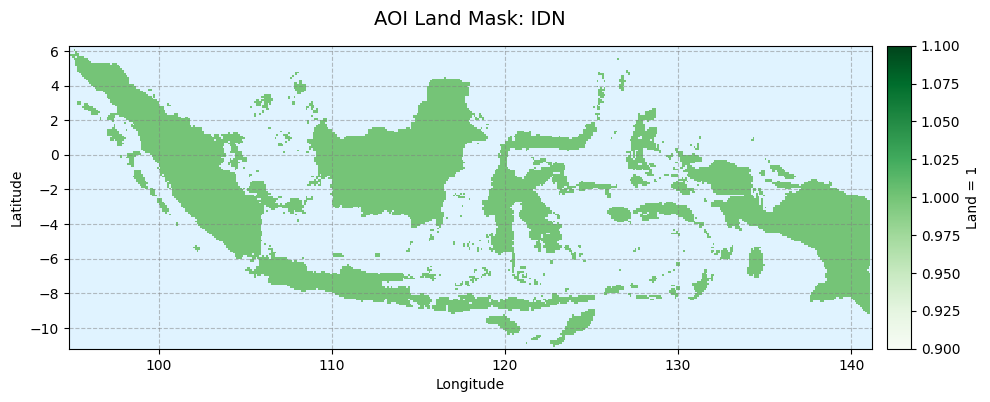

✅ Plot complete


In [14]:
# Preview AOI land mask using pure Matplotlib
import os
import xarray as xr
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable  # <-- Imported the layout tool

def load_aoi_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading AOI mask from {path} …")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Mask file not found: {path}\nDid you run the rasterization step for {TARGET_ISO3}?")

    da = xr.open_dataarray(path)
    print("✔️ AOI mask loaded")
    return da

def ensure_lat_ascending(da: xr.DataArray) -> xr.DataArray:
    if da.lat[0] > da.lat[-1]:
        print("⏳ Sorting latitudes ascending …")
        da = da.sortby('lat')
        print("✔️ Latitudes sorted")
    else:
        print("✔️ Latitudes already ascending")
    return da

def plot_mask(da: xr.DataArray, iso3_code: str):
    print("⏳ Plotting AOI mask …")
    lon = da.lon.values
    lat = da.lat.values
    z = da.values

    fig, ax = plt.subplots(figsize=(10, 6))

    # Set the background to light blue so the NaN (water) pixels look like an ocean
    ax.set_facecolor('#e0f3ff')

    mesh = ax.pcolormesh(
        lon, lat, z,
        cmap='Greens',      # Land will be green
        shading='auto'
    )

    # Keep the aspect ratio equal so the country doesn't look stretched or squished
    ax.set_aspect('equal', adjustable='box')

    # --- NEW COLORBAR LOGIC ---
    # Create a divider to lock the colorbar to the exact height of the axes
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.15)
    cbar = plt.colorbar(mesh, cax=cax, label='Land = 1')
    # --------------------------

    # Add standard gridlines
    ax.grid(True, linestyle='--', color='gray', alpha=0.5)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"AOI Land Mask: {iso3_code}", fontsize=14, pad=15)

    plt.tight_layout()
    plt.show()
    print("✅ Plot complete")

def main():
    try:
        # Dynamically build the filename using TARGET_ISO3 from the previous cell
        filename = f"{TARGET_ISO3.lower()}_land_mask.nc"
        mask_path = os.path.join(main_dir, 'data/mask/iso3', filename)

        print(f"==================================================")
        print(f"🗺️ PREVIEWING MASK FOR: {TARGET_ISO3}")
        print(f"==================================================")

        da_mask = load_aoi_mask(mask_path)
        da_mask = ensure_lat_ascending(da_mask)
        plot_mask(da_mask, TARGET_ISO3)

    except NameError:
        print("❌ Error: 'TARGET_ISO3' or 'main_dir' is not defined. Please run the previous cells first.")
    except Exception as e:
        print(f"❌ Error during preview: {e}")

# Run
if __name__ == "__main__":
    main()

#### 4.2.2 Bounding Box/Custom Polygon

In cases where the AOI does not neatly align with country boundaries, we can define it using a bounding box or a custom polygon. This provides more flexibility when working with specific regions that don't correspond to administrative borders.

We’ll walk through how to generate an AOI using a bounding box or a polygon defined by a GeoJSON text from tools such as [geojson.io](https://geojson.io). This method is particularly useful when analyzing non-administrative regions or when the focus area extends beyond country boundaries.

In [17]:
# Generate and save AOI-specific land mask from GeoJSON input
import os
import json
import time
import geopandas as gpd
import numpy as np
import xarray as xr
from rasterio import features
from affine import Affine

# =====================================================================
# ⚙️ CONFIGURATION BLOCK
# =====================================================================
CUSTOM_AOI_NAME = 'sumba'  # Name your output (e.g., 'sumbawa_bbox')

GEOJSON_INPUT = """
{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [118.59479107734273, -9.01996206314675],
            [118.59479107734273, -10.672698952161383],
            [121.2472837636185, -10.672698952161383],
            [121.2472837636185, -9.01996206314675],
            [118.59479107734273, -9.01996206314675]
          ]
        ]
      }
    }
  ]
}
"""
# =====================================================================

def format_size(bytes_size):
    for unit in ['B', 'KB', 'MB', 'GB']:
        if bytes_size < 1024.0:
            return f"{bytes_size:.2f} {unit}"
        bytes_size /= 1024.0

def load_world_mask(path: str) -> xr.DataArray:
    print(f"==================================================")
    print(f"🌍 STEP 1: LOADING GLOBAL MASK")
    print(f"==================================================")
    print(f"⏳ Loading world land mask from {path} …")
    da = xr.open_dataarray(path)
    print("✔️ World land mask loaded\n")
    return da

def load_aoi_from_geojson(geojson_text: str) -> gpd.GeoDataFrame:
    print(f"==================================================")
    print(f"🗺️ STEP 2: PARSING GEOJSON")
    print(f"==================================================")
    print("⏳ Parsing AOI from GeoJSON input …")
    try:
        gj = json.loads(geojson_text)
        gdf = gpd.GeoDataFrame.from_features(gj["features"])
        gdf.set_crs("EPSG:4326", inplace=True)
        print(f"✔️ Loaded AOI with {len(gdf)} feature(s)\n")
        return gdf
    except Exception as e:
        raise RuntimeError(f"Failed to parse GeoJSON: {e}")

def rasterize_perfect_snap(aoi_gdf: gpd.GeoDataFrame, world_da: xr.DataArray) -> xr.DataArray:
    print(f"==================================================")
    print(f"✂️ STEP 3: GRID SNAPPING & RASTERIZING")
    print(f"==================================================")
    t0 = time.time()

    # Get global coordinates
    lon = world_da['lon'].values
    lat = world_da['lat'].values
    res = float(abs(lon[1] - lon[0]))

    # Find bounding box
    minx, miny, maxx, maxy = aoi_gdf.total_bounds

    # Match bounding box to global grid indices
    lon_idx = np.where((lon >= minx) & (lon <= maxx))[0]
    lat_idx = np.where((lat >= miny) & (lat <= maxy))[0]

    # 2-pixel buffer
    pad = 2
    lon_start = max(0, lon_idx[0] - pad)
    lon_end = min(len(lon) - 1, lon_idx[-1] + pad)
    lat_start = max(0, lat_idx[0] - pad)
    lat_end = min(len(lat) - 1, lat_idx[-1] + pad)

    # Slice the global map directly
    da_sub = world_da.isel(lon=slice(lon_start, lon_end + 1), lat=slice(lat_start, lat_end + 1))

    lon_sub = da_sub['lon'].values
    lat_sub = da_sub['lat'].values
    h, w = len(lat_sub), len(lon_sub)
    print(f"✔️ Grid safely subsetted to: ({h} rows x {w} cols)")

    # Create the Transform strictly based on the subset coordinates
    lon_edge = lon_sub[0] - (res / 2.0)
    is_lat_descending = lat_sub[0] > lat_sub[-1]
    lat_edge = lat_sub[0] + (res / 2.0 if is_lat_descending else -res / 2.0)
    lat_scale = -res if is_lat_descending else res

    transform = Affine.translation(lon_edge, lat_edge) * Affine.scale(res, lat_scale)

    print("⏳ Rasterizing AOI onto snapped grid …")
    shapes = ((geom, 1) for geom in aoi_gdf.geometry)
    rast = features.rasterize(
        shapes=shapes,
        out_shape=(h, w),
        transform=transform,
        fill=0,
        dtype='uint8',
        all_touched=True
    )

    # Generate clean output based on rasterization
    clipped = np.where(rast == 1, 1.0, np.nan)

    da_aoi = xr.DataArray(
        clipped,
        coords={'lat': lat_sub, 'lon': lon_sub},
        dims=['lat', 'lon'],
        name='land'
    )

    da_aoi.attrs.update({
        'description': f'AOI land mask for {CUSTOM_AOI_NAME} (1=land, NaN elsewhere)',
        'grid_resolution': f'{res}°',
        'units': '1 / NaN'
    })

    print(f"✔️ AOI rasterized perfectly with 0 shift in {time.time()-t0:.2f} seconds.\n")
    return da_aoi

def save_aoi_mask(da: xr.DataArray, out_path: str):
    print(f"==================================================")
    print(f"💾 STEP 4: SAVING NETCDF")
    print(f"==================================================")
    print(f"⏳ Saving AOI mask to {out_path} …")
    da.to_netcdf(out_path)
    file_size = os.path.getsize(out_path)
    print(f"✅ Saved! ({format_size(file_size)})")

def main():
    try:
        world_nc = os.path.join(main_dir, 'data/mask/world/wld_land_mask.nc')

        out_dir = os.path.join(main_dir, 'data/mask/aoi')
        os.makedirs(out_dir, exist_ok=True)

        # Dynamically name the output file
        out_file = os.path.join(out_dir, f'{CUSTOM_AOI_NAME}_land_mask.nc')

        world_da = load_world_mask(world_nc)
        aoi_gdf = load_aoi_from_geojson(GEOJSON_INPUT)
        da_aoi = rasterize_perfect_snap(aoi_gdf, world_da)
        save_aoi_mask(da_aoi, out_file)

        print(f"\n🎉 Pipeline complete. Output: {CUSTOM_AOI_NAME}_land_mask.nc")

    except Exception as e:
        print(f"\n❌ Error: {e}")

# Run
if __name__ == "__main__":
    main()

🌍 STEP 1: LOADING GLOBAL MASK
⏳ Loading world land mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/world/wld_land_mask.nc …
✔️ World land mask loaded

🗺️ STEP 2: PARSING GEOJSON
⏳ Parsing AOI from GeoJSON input …
✔️ Loaded AOI with 1 feature(s)

✂️ STEP 3: GRID SNAPPING & RASTERIZING
✔️ Grid safely subsetted to: (21 rows x 30 cols)
⏳ Rasterizing AOI onto snapped grid …
✔️ AOI rasterized perfectly with 0 shift in 0.01 seconds.

💾 STEP 4: SAVING NETCDF
⏳ Saving AOI mask to /content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/sumba_land_mask.nc …
✅ Saved! (14.12 KB)

🎉 Pipeline complete. Output: sumba_land_mask.nc


Next, we’ll visualize the generated output.

🗺️ PREVIEWING MASK FOR: sumba
⏳ Loading AOI mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/sumba_land_mask.nc …
✔️ AOI mask loaded
⏳ Sorting latitudes ascending …
⏳ Plotting AOI mask …
⏳ Extracting contextual borders directly from disk (Buffer: 0.5°)...
✔️ Extracted 1 neighboring border polygons for context.


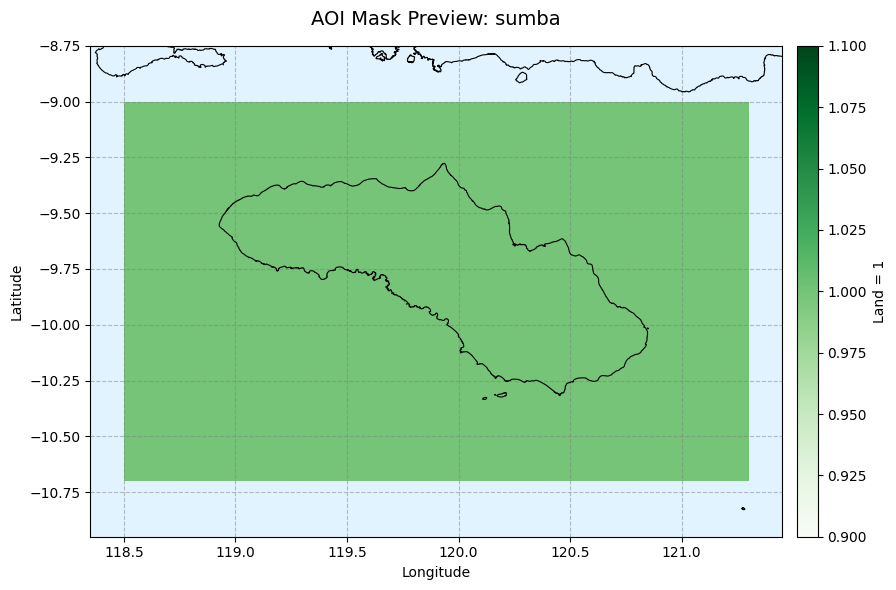

✅ Plot complete. Temporary boundary memory automatically released!


In [20]:
# Preview AOI land mask with contextual boundaries using pure Matplotlib
import os
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# =====================================================================
# ⚙️ CONFIGURATION BLOCK
# =====================================================================
# Choose what you want to preview right now:
PREVIEW_MODE = 'aoi'  # Options: 'aoi' (for GeoJSON) or 'iso3' (for Country)
# =====================================================================

def load_aoi_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading AOI mask from {path} …")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Mask file not found:\n{path}\nDid you run the generation step first?")

    da = xr.open_dataarray(path)
    print("✔️ AOI mask loaded")
    return da

def load_buffered_boundaries(gpkg_path: str, bounds: tuple, buffer: float = 0.5) -> gpd.GeoDataFrame:
    """
    Extracts a lightweight subset of global boundaries based on a buffered bounding box.
    """
    minx, miny, maxx, maxy = bounds

    # Expand the bounding box by the buffer amount
    bbox = (minx - buffer, miny - buffer, maxx + buffer, maxy + buffer)

    print(f"⏳ Extracting contextual borders directly from disk (Buffer: {buffer}°)...")
    # OPTIMIZATION: 'bbox' pushdown prevents loading the massive file into memory!
    bg_gdf = gpd.read_file(gpkg_path, engine="pyogrio", bbox=bbox)
    print(f"✔️ Extracted {len(bg_gdf)} neighboring border polygons for context.")

    return bg_gdf

def ensure_lat_ascending(da: xr.DataArray) -> xr.DataArray:
    if da.lat[0] > da.lat[-1]:
        print("⏳ Sorting latitudes ascending …")
        da = da.sortby('lat')
    return da

def plot_mask_with_borders(da: xr.DataArray, gpkg_path: str, title_name: str):
    print("⏳ Plotting AOI mask …")
    lon = da.lon.values
    lat = da.lat.values
    z = da.values

    # Calculate bounding box of the raster mask
    minx, maxx = lon.min(), lon.max()
    miny, maxy = lat.min(), lat.max()

    # Fetch only boundaries that fit in this box
    borders_gdf = load_buffered_boundaries(gpkg_path, bounds=(minx, miny, maxx, maxy), buffer=0.5)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor('#e0f3ff') # Ocean color

    # Draw the Raster
    mesh = ax.pcolormesh(
        lon, lat, z,
        cmap='Greens',
        shading='auto',
        zorder=1
    )

    # Draw Contextual Boundaries (only if borders exist in this box)
    if not borders_gdf.empty:
        borders_gdf.plot(
            ax=ax,
            facecolor='none',
            edgecolor='black',
            linewidth=0.8,
            linestyle='-',
            zorder=2
        )

    ax.set_aspect('equal', adjustable='box')

    # Lock colorbar to map height
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.15)
    plt.colorbar(mesh, cax=cax, label='Land = 1')

    # Lock plot limits so neighboring borders don't stretch the view
    ax.set_xlim(minx - 0.1, maxx + 0.1)
    ax.set_ylim(miny - 0.1, maxy + 0.1)

    ax.grid(True, linestyle='--', color='gray', alpha=0.5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"AOI Mask Preview: {title_name}", fontsize=14, pad=15)

    plt.tight_layout()
    plt.show()
    print("✅ Plot complete. Temporary boundary memory automatically released!")

def main():
    try:
        # Dynamically link to the correct variable from previous cells!
        if PREVIEW_MODE == 'aoi':
            target_name = CUSTOM_AOI_NAME
            filename = f"{target_name}_land_mask.nc"
            mask_path = os.path.join(main_dir, 'data/mask/aoi', filename)
        elif PREVIEW_MODE == 'iso3':
            target_name = TARGET_ISO3
            filename = f"{target_name.lower()}_land_mask.nc"
            mask_path = os.path.join(main_dir, 'data/mask/iso3', filename)
        else:
            raise ValueError("PREVIEW_MODE must be either 'aoi' or 'iso3'")

        gpkg_path = os.path.join(main_dir, 'data/downloads/boundary/adm0_polygons.gpkg')

        print(f"==================================================")
        print(f"🗺️ PREVIEWING MASK FOR: {target_name}")
        print(f"==================================================")

        da_mask = load_aoi_mask(mask_path)
        da_mask = ensure_lat_ascending(da_mask)
        plot_mask_with_borders(da_mask, gpkg_path, target_name)

    except NameError as e:
        print(f"❌ Error: Colab forgot the variable name. Please re-run the generation cell first!\nDetails: {e}")
    except Exception as e:
        print(f"❌ Error during preview: {e}")

# Run
if __name__ == "__main__":
    main()

#### 4.2.3 User-Supplied Data

For those who have their own custom data, this option allows us to define the AOI using shapefiles, GeoJSON, or GeoPackages. This approach is especially useful for projects with non-standard administrative divisions or custom region definitions.

In this section, we describe how to load and process user-supplied vector data. Once loaded, we can rasterize the AOI to match the global land mask and proceed with further spatial analysis.

In [21]:
# Generate and save AOI-specific land mask from user-provided vector
import os
import time
import geopandas as gpd
import numpy as np
import xarray as xr
from rasterio import features
from affine import Affine

# =====================================================================
# ⚙️ CONFIGURATION BLOCK
# =====================================================================
# Place your AOI file under data/downloads/userdata/
USER_VECTOR_FILENAME = 'idn_bnd_adm1_bali.shp'
CUSTOM_AOI_NAME = 'bali_subset'  # The name for your output file
# =====================================================================

def format_size(bytes_size):
    for unit in ['B', 'KB', 'MB', 'GB']:
        if bytes_size < 1024.0:
            return f"{bytes_size:.2f} {unit}"
        bytes_size /= 1024.0

def load_world_mask(path: str) -> xr.DataArray:
    print(f"==================================================")
    print(f"🌍 STEP 1: LOADING GLOBAL MASK")
    print(f"==================================================")
    print(f"⏳ Loading world land mask from {path} …")
    da = xr.open_dataarray(path)
    print("✔️ World land mask loaded\n")
    return da

def load_aoi(aoi_path: str) -> gpd.GeoDataFrame:
    print(f"==================================================")
    print(f"📁 STEP 2: LOADING USER VECTOR")
    print(f"==================================================")
    print(f"⏳ Loading AOI from {aoi_path} …")

    # Use Pyogrio for speed if supported, fall back to default if needed
    try:
        gdf = gpd.read_file(aoi_path, engine="pyogrio")
    except:
        gdf = gpd.read_file(aoi_path)

    print(f"✔️ Loaded {len(gdf)} feature(s)")

    # CRITICAL FIX: Ensure user data matches the global map's projection
    if gdf.crs != "EPSG:4326":
        print(f"⏳ Reprojecting user data from {gdf.crs} to EPSG:4326 …")
        gdf = gdf.to_crs("EPSG:4326")
        print("✔️ Reprojection complete")

    print("")
    return gdf

def rasterize_perfect_snap(aoi_gdf: gpd.GeoDataFrame, world_da: xr.DataArray) -> xr.DataArray:
    print(f"==================================================")
    print(f"✂️ STEP 3: GRID SNAPPING & RASTERIZING")
    print(f"==================================================")
    t0 = time.time()

    # 1. Protect against memory crashes (Explode & Simplify)
    print("⏳ Exploding polygons and simplifying to protect memory...")
    aoi_gdf = aoi_gdf.explode(ignore_index=True)
    orig_geoms = aoi_gdf.geometry.copy()
    aoi_gdf['geometry'] = aoi_gdf.geometry.simplify(tolerance=0.02, preserve_topology=False)

    collapsed = aoi_gdf.geometry.is_empty | ~aoi_gdf.geometry.type.str.contains('Polygon')
    if collapsed.sum() > 0:
        aoi_gdf.loc[collapsed, 'geometry'] = orig_geoms[collapsed]

    # 2. Get global coordinates
    lon = world_da['lon'].values
    lat = world_da['lat'].values
    res = float(abs(lon[1] - lon[0]))

    # 3. Find bounding box to subset the grid
    minx, miny, maxx, maxy = aoi_gdf.total_bounds
    lon_idx = np.where((lon >= minx) & (lon <= maxx))[0]
    lat_idx = np.where((lat >= miny) & (lat <= maxy))[0]

    pad = 2
    lon_start = max(0, lon_idx[0] - pad)
    lon_end = min(len(lon) - 1, lon_idx[-1] + pad)
    lat_start = max(0, lat_idx[0] - pad)
    lat_end = min(len(lat) - 1, lat_idx[-1] + pad)

    # Slice the global map directly
    da_sub = world_da.isel(lon=slice(lon_start, lon_end + 1), lat=slice(lat_start, lat_end + 1))

    lon_sub = da_sub['lon'].values
    lat_sub = da_sub['lat'].values
    h, w = len(lat_sub), len(lon_sub)
    print(f"✔️ Grid safely subsetted to: ({h} rows x {w} cols)")

    # 4. Create local transform
    lon_edge = lon_sub[0] - (res / 2.0)
    is_lat_descending = lat_sub[0] > lat_sub[-1]
    lat_edge = lat_sub[0] + (res / 2.0 if is_lat_descending else -res / 2.0)
    lat_scale = -res if is_lat_descending else res

    transform = Affine.translation(lon_edge, lat_edge) * Affine.scale(res, lat_scale)

    print("⏳ Rasterizing AOI onto snapped grid …")
    shapes = ((geom, 1) for geom in aoi_gdf.geometry)
    rast = features.rasterize(
        shapes=shapes,
        out_shape=(h, w),
        transform=transform,
        fill=0,
        dtype='uint8',
        all_touched=True
    )

    # Generate clean output based on rasterization
    clipped = np.where(rast == 1, 1.0, np.nan)

    da_aoi = xr.DataArray(
        clipped,
        coords={'lat': lat_sub, 'lon': lon_sub},
        dims=['lat', 'lon'],
        name='land'
    )

    da_aoi.attrs.update({
        'description': f'AOI land mask for {CUSTOM_AOI_NAME} (1=land, NaN elsewhere)',
        'grid_resolution': f'{res}°',
        'units': '1 / NaN'
    })

    print(f"✔️ AOI rasterized perfectly with 0 shift in {time.time()-t0:.2f} seconds.\n")
    return da_aoi

def save_aoi_mask(da: xr.DataArray, out_path: str):
    print(f"==================================================")
    print(f"💾 STEP 4: SAVING NETCDF")
    print(f"==================================================")
    print(f"⏳ Saving AOI mask to {out_path} …")
    da.to_netcdf(out_path)
    file_size = os.path.getsize(out_path)
    print(f"✅ Saved! ({format_size(file_size)})")

def main():
    try:
        world_nc = os.path.join(main_dir, 'data/mask/world/wld_land_mask.nc')

        userdata_dir = os.path.join(main_dir, 'data/downloads/userdata')
        aoi_path = os.path.join(userdata_dir, USER_VECTOR_FILENAME)

        if not os.path.exists(aoi_path):
            raise FileNotFoundError(f"User vector file not found: {aoi_path}")

        out_dir = os.path.join(main_dir, 'data/mask/aoi')
        os.makedirs(out_dir, exist_ok=True)

        # Output named dynamically based on CUSTOM_AOI_NAME
        out_file = os.path.join(out_dir, f'{CUSTOM_AOI_NAME}.nc')

        world_da = load_world_mask(world_nc)
        aoi_gdf = load_aoi(aoi_path)
        da_aoi = rasterize_perfect_snap(aoi_gdf, world_da)
        save_aoi_mask(da_aoi, out_file)

        print(f"\n🎉 Pipeline complete. Output: {CUSTOM_AOI_NAME}.nc")

    except Exception as e:
        print(f"\n❌ Error: {e}")

# Run
if __name__ == "__main__":
    main()

🌍 STEP 1: LOADING GLOBAL MASK
⏳ Loading world land mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/world/wld_land_mask.nc …
✔️ World land mask loaded

📁 STEP 2: LOADING USER VECTOR
⏳ Loading AOI from /content/drive/MyDrive/hybrid-bias-correction/data/downloads/userdata/idn_bnd_adm1_bali.shp …
✔️ Loaded 1 feature(s)

✂️ STEP 3: GRID SNAPPING & RASTERIZING
⏳ Exploding polygons and simplifying to protect memory...
✔️ Grid safely subsetted to: (11 rows x 17 cols)
⏳ Rasterizing AOI onto snapped grid …
✔️ AOI rasterized perfectly with 0 shift in 0.04 seconds.

💾 STEP 4: SAVING NETCDF
⏳ Saving AOI mask to /content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/bali_subset.nc …
✅ Saved! (9.19 KB)

🎉 Pipeline complete. Output: bali_subset.nc


Next, we’ll visualize the generated output.

🗺️ PREVIEWING MASK FOR: bali_subset
⏳ Loading AOI mask from /content/drive/MyDrive/hybrid-bias-correction/data/mask/aoi/bali_subset.nc …
✔️ AOI mask loaded
⏳ Plotting AOI mask …
⏳ Extracting contextual borders directly from disk (Buffer: 0.5°)...
✔️ Extracted 1 neighboring border polygons for context.


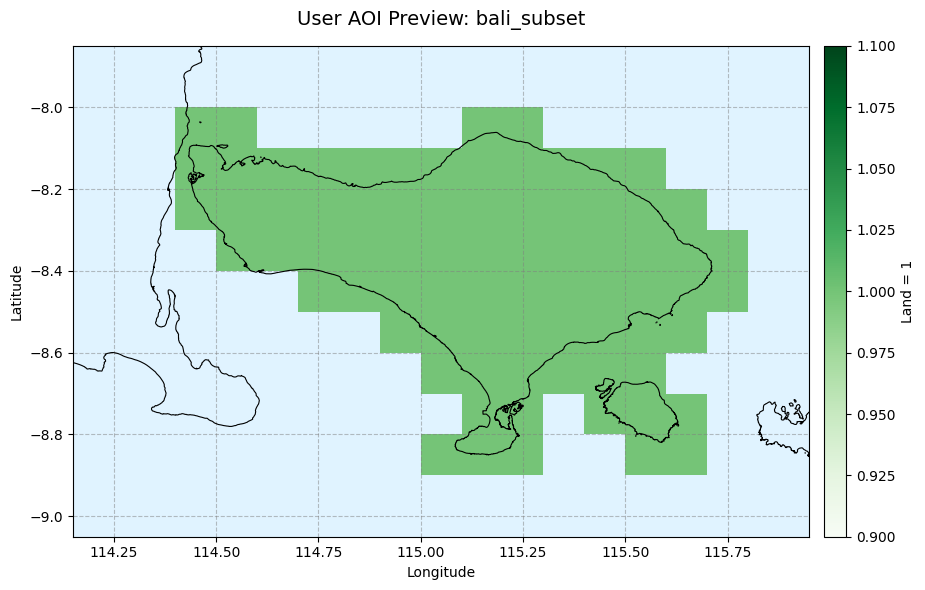

✅ Plot complete. Temporary boundary memory released!


In [22]:
# Preview user AOI mask with contextual boundaries using pure Matplotlib
import os
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def load_aoi_mask(path: str) -> xr.DataArray:
    print(f"⏳ Loading AOI mask from {path} …")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Mask file not found:\n{path}\nDid you run the generation step first?")
    da = xr.open_dataarray(path)
    print("✔️ AOI mask loaded")
    return da

def load_buffered_boundaries(gpkg_path: str, bounds: tuple, buffer: float = 0.5) -> gpd.GeoDataFrame:
    minx, miny, maxx, maxy = bounds
    bbox = (minx - buffer, miny - buffer, maxx + buffer, maxy + buffer)

    print(f"⏳ Extracting contextual borders directly from disk (Buffer: {buffer}°)...")
    bg_gdf = gpd.read_file(gpkg_path, engine="pyogrio", bbox=bbox)
    print(f"✔️ Extracted {len(bg_gdf)} neighboring border polygons for context.")
    return bg_gdf

def ensure_lat_ascending(da: xr.DataArray) -> xr.DataArray:
    if da.lat[0] > da.lat[-1]:
        da = da.sortby('lat')
    return da

def plot_mask_with_borders(da: xr.DataArray, gpkg_path: str, title_name: str):
    print("⏳ Plotting AOI mask …")
    lon = da.lon.values
    lat = da.lat.values
    z = da.values

    # Calculate bounding box
    minx, maxx = lon.min(), lon.max()
    miny, maxy = lat.min(), lat.max()

    # Fetch neighboring borders
    borders_gdf = load_buffered_boundaries(gpkg_path, bounds=(minx, miny, maxx, maxy), buffer=0.5)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor('#e0f3ff') # Ocean color

    # Draw Raster
    mesh = ax.pcolormesh(lon, lat, z, cmap='Greens', shading='auto', zorder=1)

    # Draw Borders
    if not borders_gdf.empty:
        borders_gdf.plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.8, linestyle='-', zorder=2
        )

    ax.set_aspect('equal', adjustable='box')

    # Lock colorbar height
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.15)
    plt.colorbar(mesh, cax=cax, label='Land = 1')

    # Lock viewport
    ax.set_xlim(minx - 0.1, maxx + 0.1)
    ax.set_ylim(miny - 0.1, maxy + 0.1)

    ax.grid(True, linestyle='--', color='gray', alpha=0.5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"User AOI Preview: {title_name}", fontsize=14, pad=15)

    plt.tight_layout()
    plt.show()
    print("✅ Plot complete. Temporary boundary memory released!")

def main():
    try:
        # Dynamically link to CUSTOM_AOI_NAME from the previous cell
        filename = f"{CUSTOM_AOI_NAME}.nc"
        mask_path = os.path.join(main_dir, 'data/mask/aoi', filename)
        gpkg_path = os.path.join(main_dir, 'data/downloads/boundary/adm0_polygons.gpkg')

        print(f"==================================================")
        print(f"🗺️ PREVIEWING MASK FOR: {CUSTOM_AOI_NAME}")
        print(f"==================================================")

        da_mask = load_aoi_mask(mask_path)
        da_mask = ensure_lat_ascending(da_mask)
        plot_mask_with_borders(da_mask, gpkg_path, CUSTOM_AOI_NAME)

    except NameError:
        print("❌ Error: Colab forgot 'CUSTOM_AOI_NAME'. Please re-run the generation cell first!")
    except Exception as e:
        print(f"❌ Error during preview: {e}")

# Run
if __name__ == "__main__":
    main()

## 5 Summary

In this notebook we established the spatial foundation for the bias-correction workflow:

1. **Global land mask** (Section 4.1) -- We downloaded admin-0 boundaries from Fieldmaps.io and rasterized them onto a 0.1-degree grid aligned with the IMERG satellite precipitation product. The result is a global binary mask (1 = land, NaN = water) stored as NetCDF.

2. **AOI extraction** (Section 4.2) -- Using the global mask as a starting point, we demonstrated three approaches to define an Area of Interest:
   - **Country boundaries** (4.2.1) -- Filter by ISO3 code to obtain a national-level mask (example: Sri Lanka, `LKA`).
   - **Bounding box / custom polygon** (4.2.2) -- Paste a GeoJSON geometry (e.g. from [geojson.io](https://geojson.io)) to clip an arbitrary rectangular or polygonal region.
   - **User-supplied vector data** (4.2.3) -- Load a local shapefile, GeoPackage, or GeoJSON file for non-standard AOI definitions.

Each method produces a grid-aligned NetCDF land mask that is directly usable by the downstream notebooks. The mask is applied during bias correction (notebook 02), metric computation (notebook 03), and quality assessment (notebook 04) to restrict processing to land pixels within the target domain.

**Next step**: Proceed to **Notebook 01 -- Data Acquisition** to download the IMERG and CPC-UNI precipitation datasets for the AOI defined here.